<a href="https://colab.research.google.com/github/Bacchia/Facial-Expression-Recognition/blob/main/notebooks/FER_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Bacchia/Facial-Expression-Recognition.git

Cloning into 'Facial-Expression-Recognition'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 23 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 8.10 KiB | 1.35 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [2]:
%cd Facial-Expression-Recognition

/content/Facial-Expression-Recognition


In [3]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 11.0 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [4]:
import os

os.environ['KAGGLE_USERNAME'] = "sabalosaberidze"
os.environ['KAGGLE_KEY'] = "KGAT_5e31e15f960247eebca89596c2d04f40"


In [5]:
!kaggle datasets list

ref                                                                    title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                                      Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000          11132        273                1  
kulkarniparth09/fifa-world-cup-complete-dataset-19302026               FIFA World Cup Complete Dataset: 1930–2026               11953  2026-06-07 06:29:15.677000           1532         38                1  
sateasinpedas/global-geo-economic-stress-indicators                    Global Geo-Economic Stress Indicators                  1105907  2026-06-07 15:37:49.907000           

In [7]:
!kaggle competitions list --search facial

ref                                                                                  deadline             category            reward  teamCount  userHasEntered  
-----------------------------------------------------------------------------------  -------------------  ---------------  ---------  ---------  --------------  
https://www.kaggle.com/competitions/anip-reconnaissance-faciale-estimation-ages-ocr  2025-10-17 10:00:00  Community        1,350 Usd          0           False  
https://www.kaggle.com/competitions/facial-keypoints-detection                       2017-01-07 00:00:00  Getting Started  Knowledge        175           False  
https://www.kaggle.com/competitions/cs194-26-fall-2021-project-5                     2021-11-21 07:59:00  Community            Kudos        153           False  
https://www.kaggle.com/competitions/cs194-26-fall-2022-project-5                     2022-11-20 07:59:00  Community            Kudos        137           False  
https://www.kaggle.com/compe

In [8]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:01<00:00, 186MB/s]



In [9]:
!unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d /content/Facial-Expression-Recognition

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: /content/Facial-Expression-Recognition/example_submission.csv  
  inflating: /content/Facial-Expression-Recognition/fer2013.tar.gz  
  inflating: /content/Facial-Expression-Recognition/icml_face_data.csv  
  inflating: /content/Facial-Expression-Recognition/test.csv  
  inflating: /content/Facial-Expression-Recognition/train.csv  


In [10]:
%cd /content/Facial-Expression-Recognition

/content/Facial-Expression-Recognition


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
train_df = pd.read_csv("train.csv")

train_df.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [13]:
train_df.shape

(28709, 2)

In [14]:
train_df["emotion"].value_counts()

,count
emotion,
3,7215
6,4965
4,4830
2,4097
0,3995
5,3171
1,436


In [15]:
emotion_names = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]


def show_image(index):

    pixels = train_df.iloc[index]["pixels"]

    img = np.array(
        pixels.split(),
        dtype=np.uint8
    )

    img = img.reshape(48,48)

    plt.imshow(img,cmap="gray")
    plt.title(emotion_names[train_df.iloc[index]["emotion"]])
    plt.axis("off")

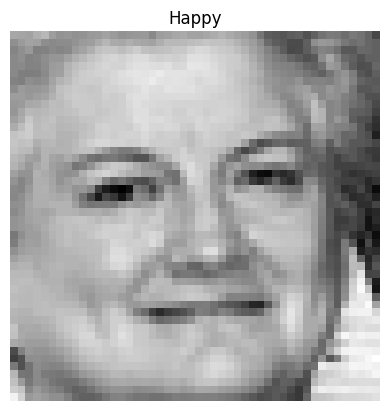

In [16]:
show_image(100)

In [17]:
import torch
from torch.utils.data import Dataset


class FERDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe


    def __len__(self):

        return len(self.df)


    def __getitem__(self,idx):

        row=self.df.iloc[idx]

        pixels=np.array(
            row["pixels"].split(),
            dtype=np.float32
        )

        image=pixels.reshape(48,48)

        image=image/255.0


        image=torch.tensor(image)

        image=image.unsqueeze(0)


        label=torch.tensor(
            row["emotion"],
            dtype=torch.long
        )


        return image,label

In [18]:
dataset = FERDataset(train_df)

img,label = dataset[0]

img.shape, label

(torch.Size([1, 48, 48]), tensor(0))

In [19]:
from sklearn.model_selection import train_test_split


train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["emotion"]
)

In [20]:
from torch.utils.data import DataLoader


train_loader = DataLoader(
    FERDataset(train_data),
    batch_size=64,
    shuffle=True
)


val_loader = DataLoader(
    FERDataset(val_data),
    batch_size=64
)